In [6]:
!pip install wfdb
import wfdb
import matplotlib.pyplot as plt



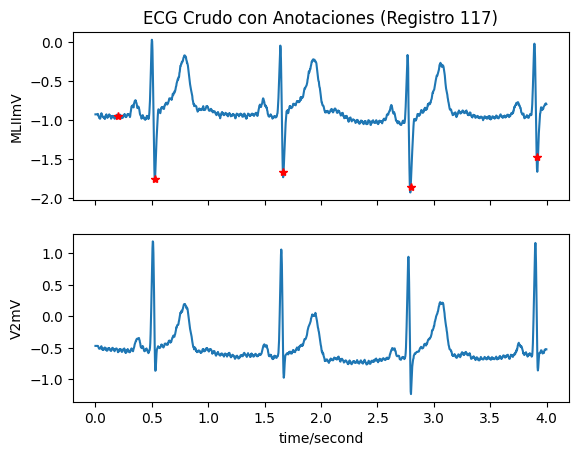

In [13]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

#1.Definir registro y base de datos
record_name = '117'
db_path = 'mitdb'

#Cargar registro completo y anotaciones para el procesamiento matemático
record = wfdb.rdrecord(record_name, pn_dir=db_path)
annotation = wfdb.rdann(record_name, 'atr', pn_dir=db_path)

x = record.p_signal[:, 0]  #Usamos el canal 0 (generalmente la derivación MLII)
fs = record.fs             #360 Hz

#Visualización rápida con la herramienta nativa (solo los primeros 4 segundos)
record_vis = wfdb.rdrecord(record_name, pn_dir=db_path, sampto=1440)
ann_vis = wfdb.rdann(record_name, 'atr', pn_dir=db_path, sampto=1440)

wfdb.plot_wfdb(record=record_vis, annotation=ann_vis, time_units='seconds', title="ECG Crudo con Anotaciones (Registro 117)")

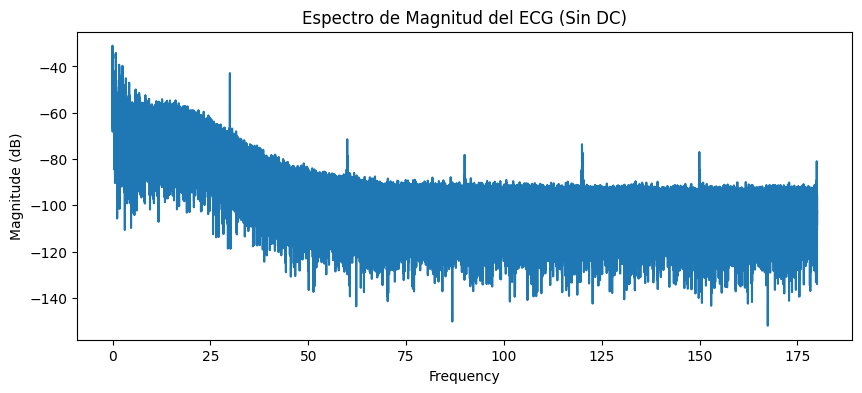

In [15]:
# 2.Remover el offset (Componente DC)
x_dc_removed = x - np.mean(x)

#Graficar el espectro de magnitud en dB
plt.figure(figsize=(10, 4))
plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')
plt.title("Espectro de Magnitud del ECG (Sin DC)")
plt.show()

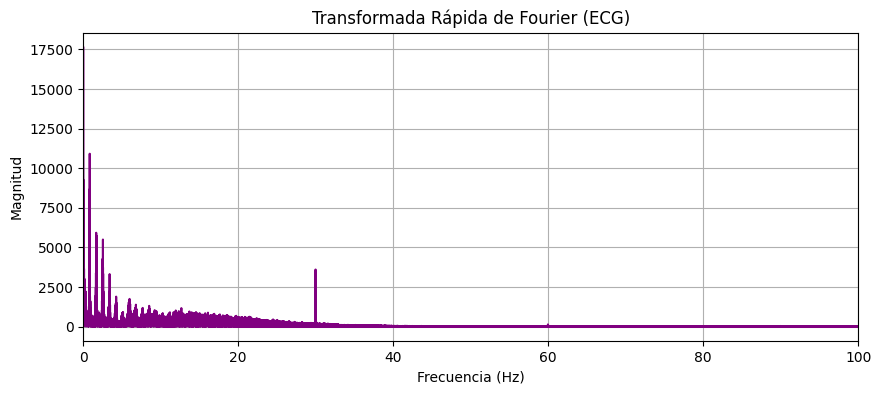

In [16]:
#3.Calcular la FFT
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)
mitad = len(x_dc_removed) // 2

plt.figure(figsize=(10, 4))
plt.plot(freqs[:mitad], np.abs(X[:mitad]), color='purple')
plt.title("Transformada Rápida de Fourier (ECG)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 100)#Hacemos zoom hasta 100 Hz porque ahí está la información útil
plt.grid(True)
plt.show()

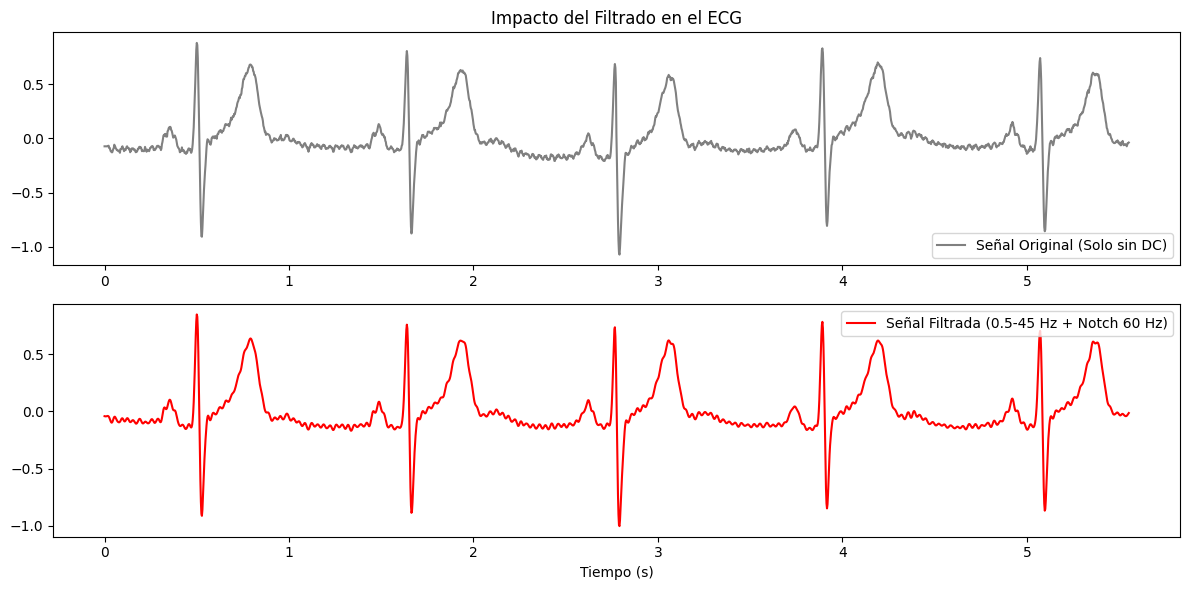

In [17]:
#4.1 Filtro Pasa Banda Butterworth (0.5 Hz a 45 Hz)
nyq = 0.5 * fs
low = 0.5 / nyq
high = 45.0 / nyq
b_band, a_band = signal.butter(4, [low, high], btype='band')
x_bandpass = signal.filtfilt(b_band, a_band, x_dc_removed)

#4.2 Filtro Notch (Rechaza-banda) para eliminar los 60 Hz
f0 = 60.0  # Frecuencia a eliminar
Q = 30.0   # Factor de calidad (qué tan estrecho es el corte)
w0 = f0 / nyq
b_notch, a_notch = signal.iirnotch(w0, Q)
x_filtered = signal.filtfilt(b_notch, a_notch, x_bandpass)

#5. Visualización del Antes y Después (dominio del tiempo)
t = np.arange(2000) / fs # Vector de tiempo para 2000 muestras

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x_dc_removed[:2000], label="Señal Original (Solo sin DC)", color='gray')
plt.legend()
plt.title("Impacto del Filtrado en el ECG")

plt.subplot(2, 1, 2)
plt.plot(t, x_filtered[:2000], label="Señal Filtrada (0.5-45 Hz + Notch 60 Hz)", color='red')
plt.xlabel("Tiempo (s)")
plt.legend()
plt.tight_layout()
plt.show()